In [20]:
import pandas as pd

df=pd.read_csv("regression-dataset-train.csv")
df.head()

,id,date,season_id,year,month,is_holiday,weekday,is_workingday,weather_condition,temperature,feels_like_temp,humidity,wind_speed,total_users
0,577,31-07-2019,3,1,7,0,2,1,1,29.246653,33.1448,70.4167,11.083475,7216
1,427,03-03-2019,1,1,3,0,6,0,2,16.980847,20.6746,62.1250,10.792293,4066
2,729,30-12-2019,1,1,12,0,0,0,1,10.489153,11.5850,48.3333,23.500518,1796
3,483,28-04-2019,2,1,4,0,6,0,2,15.443347,18.8752,48.9583,8.708325,4220
4,112,22-04-2018,2,0,4,0,5,1,2,13.803347,16.0977,72.9583,14.707907,1683


In [21]:
def convert_datetime(df:pd.DataFrame):
	df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')
	df['day'] = df['date'].dt.day
	df['week'] = df['date'].dt.isocalendar().week.astype(int)
	df['day_of_year'] = df['date'].dt.dayofyear
	return df
df=convert_datetime(df)
df.head()

,id,date,season_id,year,month,is_holiday,weekday,is_workingday,weather_condition,temperature,feels_like_temp,humidity,wind_speed,total_users,day,week,day_of_year
0,577,2019-07-31,3,1,7,0,2,1,1,29.246653,33.1448,70.4167,11.083475,7216,31,31,212
1,427,2019-03-03,1,1,3,0,6,0,2,16.980847,20.6746,62.1250,10.792293,4066,3,9,62
2,729,2019-12-30,1,1,12,0,0,0,1,10.489153,11.5850,48.3333,23.500518,1796,30,1,364
3,483,2019-04-28,2,1,4,0,6,0,2,15.443347,18.8752,48.9583,8.708325,4220,28,17,118
4,112,2018-04-22,2,0,4,0,5,1,2,13.803347,16.0977,72.9583,14.707907,1683,22,16,112


## Visualization

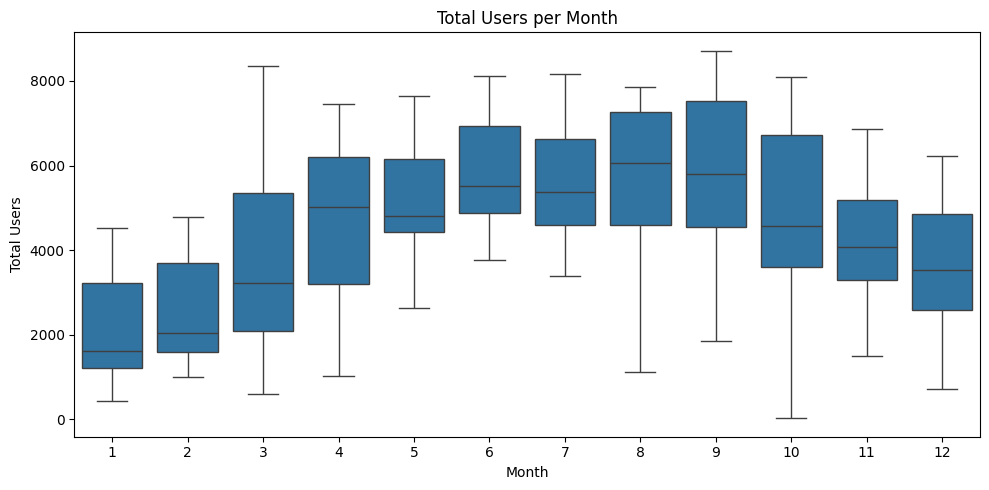

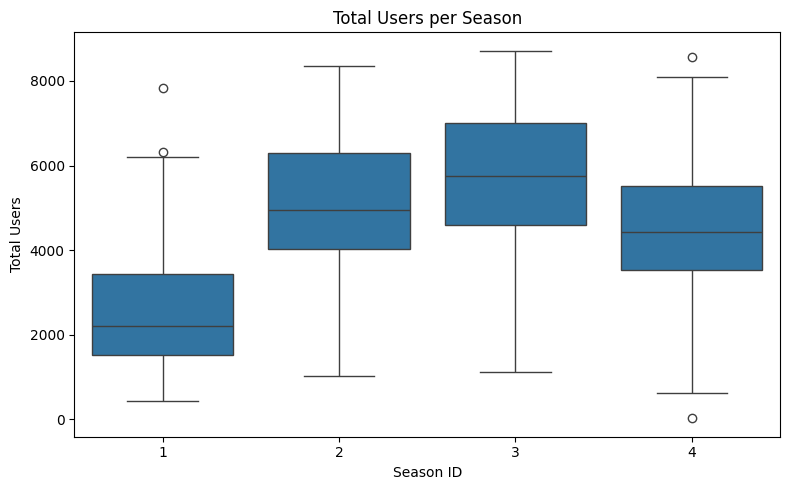

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.boxplot(x="month", y="total_users", data=df)
plt.title("Total Users per Month")
plt.xlabel("Month")
plt.ylabel("Total Users")
plt.tight_layout()
plt.show()

# Plot 2: Total Users per Season
plt.figure(figsize=(8, 5))
sns.boxplot(x="season_id", y="total_users", data=df)
plt.title("Total Users per Season")
plt.xlabel("Season ID")
plt.ylabel("Total Users")
plt.tight_layout()
plt.show()


In [23]:

def print_average_users(feature:str):
	weather_users_sum = df.groupby(feature)['total_users'].sum().reset_index()
	print(weather_users_sum)
	record_count = df.groupby(feature).size().reset_index(name='record_count')
	print(record_count)
	weather_users_sum['average_users'] = weather_users_sum['total_users'] / record_count['record_count']
	print(weather_users_sum)
print_average_users("year")



   year  total_users
0     0       831954
1     1      1455568
   year  record_count
0     0           251
1     1           259
   year  total_users  average_users
0     0       831954    3314.557769
1     1      1455568    5619.953668


/tmp/ipykernel_121071/452563935.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='is_holiday', y='total_users', data=holiday_users_sum, ci=None)


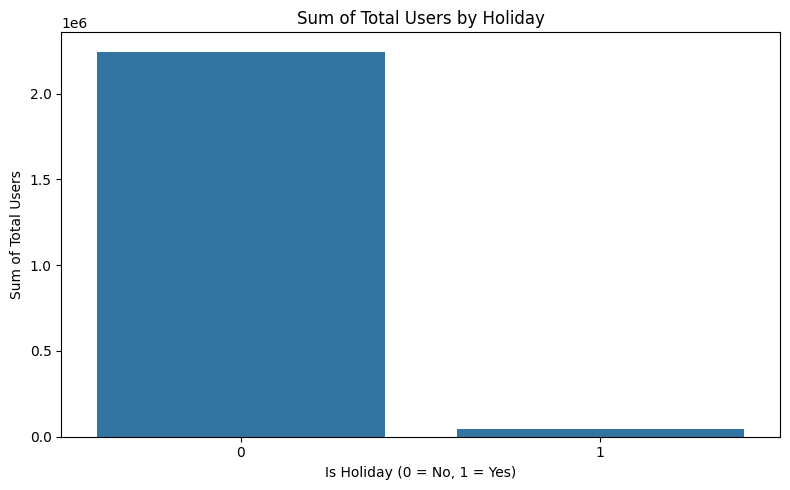

In [24]:
holiday_users_sum = df.groupby('is_holiday')['total_users'].sum().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x='is_holiday', y='total_users', data=holiday_users_sum, ci=None)
plt.title("Sum of Total Users by Holiday")
plt.xlabel("Is Holiday (0 = No, 1 = Yes)")
plt.ylabel("Sum of Total Users")
plt.tight_layout()
plt.show()

## Feature engineering

In [25]:
# Create new features
def create_new_features(df):
	df['temp_humidity_ratio'] = df['temperature'] / (df['humidity'] +10)  
	df['wind_temp_interaction'] = (1/df['wind_speed']) * df['temperature']
	# df['temp_wind_ratio'] = df['temperature'] / (df['wind_speed'] + 1)  
	df['humidity_wind_interaction'] = df['humidity'] * df['wind_speed']

	df['feels_like_dot_temp'] = df['feels_like_temp'] * df['temperature'] +(df['humidity']*df['humidity'])
	df['weather_condition_temp']=df['temperature']/df['weather_condition']
	df['wind_speed_weather_condition']=df['wind_speed']*df['weather_condition']
	df['humidity_weather_condition']=1/(df['humidity']*df['weather_condition'])
	df['year_month_ratio']= df['year'] / df['month'] 
	return df

df.head()

,id,date,season_id,year,month,is_holiday,weekday,is_workingday,weather_condition,temperature,feels_like_temp,humidity,wind_speed,total_users,day,week,day_of_year
0,577,2019-07-31,3,1,7,0,2,1,1,29.246653,33.1448,70.4167,11.083475,7216,31,31,212
1,427,2019-03-03,1,1,3,0,6,0,2,16.980847,20.6746,62.1250,10.792293,4066,3,9,62
2,729,2019-12-30,1,1,12,0,0,0,1,10.489153,11.5850,48.3333,23.500518,1796,30,1,364
3,483,2019-04-28,2,1,4,0,6,0,2,15.443347,18.8752,48.9583,8.708325,4220,28,17,118
4,112,2018-04-22,2,0,4,0,5,1,2,13.803347,16.0977,72.9583,14.707907,1683,22,16,112


## Preprocess


In [26]:

import numpy as np
def preprocess(df:pd.DataFrame):
	df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
	df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
	df['day_sin'] = np.sin(2 * np.pi * df['day'] / 31)  
	df['day_cos'] = np.cos(2 * np.pi * df['day'] / 31) 
	
	df['week_sin'] = np.sin(2 * np.pi * df['week'] / 52)  
	df['week_cos'] = np.cos(2 * np.pi * df['week'] / 52)

	df['weekday_sin'] = np.sin(2 * np.pi * df['weekday'] / 7)
	df['weekday_cos'] = np.cos(2 * np.pi * df['weekday'] / 7)

	df.drop(columns=['month','week','day','wind_speed','weather_condition','is_workingday','is_holiday',
					],inplace=True)
	return df



In [27]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler
columns_to_normalize = ['temperature', 'feels_like_temp', 'humidity','humidity_wind_interaction']
def normalize(df:pd.DataFrame,columns_to_normalize):
	scaler = StandardScaler()
	df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])	
	return df
def remove_outliers(df:pd.DataFrame,columns):
  df = df[(df[columns] <= 2).all(axis=1) & (df[columns] >= -2).all(axis=1)]
  return df


In [28]:
def prepare_test_data(df):
    df=create_new_features(df)
    df=preprocess(df)
    weekday_target_mean = df.groupby('weekday')['total_users'].mean()
    df['weekday_encoded'] = df['weekday'].map(weekday_target_mean)
    df.drop(columns=['weekday'])
    df=normalize(df,columns_to_normalize)
    df=remove_outliers(df,columns_to_normalize)
    return df,weekday_target_mean
df,weekday_target_mean=prepare_test_data(df)
df.drop(columns=['humidity'],inplace=True)
df.head()

,id,date,season_id,year,weekday,temperature,feels_like_temp,total_users,day_of_year,temp_humidity_ratio,...,year_month_ratio,month_sin,month_cos,day_sin,day_cos,week_sin,week_cos,weekday_sin,weekday_cos,weekday_encoded
0,577,2019-07-31,3,1,2,1.230870,1.193181,7216,212,0.363689,...,0.142857,-5.000000e-01,-8.660254e-01,-2.449294e-16,1.000000,-0.568065,-0.822984,0.974928,-0.222521,4638.313433
1,427,2019-03-03,1,1,6,-0.421238,-0.349583,4066,62,0.235436,...,0.333333,1.000000e+00,6.123234e-17,5.712682e-01,0.820763,0.885456,0.464723,-0.781831,0.623490,4412.518987
2,729,2019-12-30,1,1,0,-1.295618,-1.474112,1796,364,0.179814,...,0.083333,-2.449294e-16,1.000000e+00,-2.012985e-01,0.979530,0.120537,0.992709,0.000000,1.000000,4183.931507
3,483,2019-04-28,2,1,6,-0.628327,-0.572197,4220,118,0.261937,...,0.250000,8.660254e-01,-5.000000e-01,-5.712682e-01,0.820763,0.885456,-0.464723,-0.781831,0.623490,4412.518987
4,112,2018-04-22,2,0,5,-0.849222,-0.915819,1683,112,0.166389,...,0.000000,8.660254e-01,-5.000000e-01,-9.680771e-01,-0.250653,0.935016,-0.354605,-0.974928,-0.222521,4611.815385


In [29]:
from sklearn.model_selection import train_test_split
df.drop(columns=['id','date'],inplace=True)

X = df.drop(columns=['total_users'])
y = df['total_users']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [30]:
def prepare_unlabeled_data():
    unlabeled_data=pd.read_csv("regression-dataset-test-unlabeled.csv")
    unlabeled_data=convert_datetime(unlabeled_data)
    unlabeled_data.drop(columns=['id','date'],inplace=True)
    unlabeled_data=create_new_features(unlabeled_data)
    unlabeled_data=preprocess(unlabeled_data)
    unlabeled_data['weekday_encoded']=unlabeled_data['weekday'].map(weekday_target_mean)
    unlabeled_data=normalize(unlabeled_data,columns_to_normalize)
    unlabeled_data.drop(columns=['humidity'],inplace=True)
    return unlabeled_data
unlabeled_data=prepare_unlabeled_data()

In [31]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_score


def train(x_train, y_train, x_test, y_test):
		rf_model = RandomForestRegressor(
				n_estimators=1000, random_state=42, max_depth=20)
		rf_model.fit(x_train, y_train)
		y_pred = rf_model.predict(x_test)
		y_pred=pd.DataFrame(y_pred)
		perm_importance = permutation_importance(
				rf_model, x_test, y_test, n_repeats=10)
		sorted_idx = perm_importance.importances_mean.argsort()
		print("Permutation Feature Importances:")
		for idx in sorted_idx[::-1]:
				print(f"{x_train.columns[idx]}: {perm_importance.importances_mean[idx]:.4f}")
				
		mse = mean_squared_error(y_test, y_pred)
		r2 = r2_score(y_test, y_pred)
		mae = mean_squared_error(y_test, y_pred)  
		rmse = np.sqrt(mse)  
		mape = np.mean(np.abs((y_test - y_pred.values.flatten()) / y_test)) * 100  

		print(f"Mean Squared Error (MSE): {mse}")
		print(f"R^2 Score: {r2}")
		print(f"Mean Absolute Error (MAE): {mae}")
		print(f"Root Mean Squared Error (RMSE): {rmse}")
		print(f"Mean Absolute Percentage Error (MAPE): {mape}")
		
train(X_train,y_train,X_test,y_test)


Permutation Feature Importances:
year_month_ratio: 0.1487
temp_humidity_ratio: 0.1314
year: 0.1276
temperature: 0.0646
day_of_year: 0.0266
season_id: 0.0179
feels_like_temp: 0.0164
humidity_weather_condition: 0.0093
week_sin: 0.0090
feels_like_dot_temp: 0.0090
weather_condition_temp: 0.0086
wind_speed_weather_condition: 0.0069
weekday: 0.0062
day_sin: 0.0059
humidity_wind_interaction: 0.0032
month_sin: 0.0023
wind_temp_interaction: 0.0021
week_cos: 0.0019
weekday_encoded: 0.0014
month_cos: 0.0003
weekday_cos: 0.0002
weekday_sin: 0.0000
day_cos: -0.0005
Mean Squared Error (MSE): 313643.27006423054
R^2 Score: 0.91618285533684
Mean Absolute Error (MAE): 313643.27006423054
Root Mean Squared Error (RMSE): 560.038632653347
Mean Absolute Percentage Error (MAPE): 11.323509104005483


In [32]:
def test_model(unlabeled_data,x_train,y_train):
	rf_model = RandomForestRegressor(
							n_estimators=1000, random_state=42, max_depth=15)
	rf_model.fit(x_train, y_train)
	y_pred = rf_model.predict(unlabeled_data)
	y_pred=pd.DataFrame(y_pred)
	y_pred.index+=1
	y_pred.columns = ['label']
	y_pred.reset_index(names='id', inplace=True)
	y_pred.to_csv('result.csv',index=False)
test_model(unlabeled_data,X,y)
		

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Initialize the Linear Regression model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

# Predict on the test set
y_pred_lr = lr_model.predict(X_test)

# Calculate Mean Squared Error
mse_lr = mean_squared_error(y_test, y_pred_lr)

print(f"Mean Squared Error (Linear Regression): {mse_lr}")

Mean Squared Error (Linear Regression): 651268.2624769128


In [34]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error

catboost_model = CatBoostRegressor(iterations=1000, learning_rate=0.1, depth=10, random_seed=42, verbose=0)

catboost_model.fit(X_train, y_train)

y_pred_catboost = catboost_model.predict(X_test)

mse_catboost = mean_squared_error(y_test, y_pred_catboost)

print(f"Mean Squared Error (CatBoost): {mse_catboost}")

Mean Squared Error (CatBoost): 479890.373278854


In [35]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

xgb_model = XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)


feature_importances = dict(zip(X.columns, xgb_model.feature_importances_))
print("Feature Importances (XGBoost):")
for feature, importance in feature_importances.items():
	print(f"{feature}: {importance}")
 

mse_xgb = mean_squared_error(y_test, y_pred_xgb)

print(f"Mean Squared Error (XGBoost): {mse_xgb}")

Feature Importances (XGBoost):
season_id: 0.054353468120098114
year: 0.2796954810619354
weekday: 0.004627939313650131
temperature: 0.11066899448633194
feels_like_temp: 0.014462217688560486
day_of_year: 0.018856901675462723
temp_humidity_ratio: 0.2163960486650467
wind_temp_interaction: 0.010275519452989101
humidity_wind_interaction: 0.006012513767927885
feels_like_dot_temp: 0.007958953268826008
weather_condition_temp: 0.011688735336065292
wind_speed_weather_condition: 0.012165773659944534
humidity_weather_condition: 0.015656614676117897
year_month_ratio: 0.1534947156906128
month_sin: 0.0038115314673632383
month_cos: 0.0033234949223697186
day_sin: 0.00858051422983408
day_cos: 0.0056254626251757145
week_sin: 0.04532564431428909
week_cos: 0.004689390305429697
weekday_sin: 0.0027667328249663115
weekday_cos: 0.0025430144742131233
weekday_encoded: 0.0070203919894993305
Mean Squared Error (XGBoost): 323977.728057964


In [36]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

knn_model = KNeighborsRegressor(n_neighbors=5,weights='distance',metric='manhattan')

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)
mse_knn = mean_squared_error(y_test, y_pred_knn)

print(f"Mean Squared Error (KNN): {mse_knn}")

Mean Squared Error (KNN): 3158118.9945088676


In [37]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error

svr_model = SVR(kernel='rbf', C=0.01, epsilon=0.1,max_iter=10000)

svr_model.fit(X_train, y_train)

y_pred_svr = svr_model.predict(X_test)

mse_svr = mean_squared_error(y_test, y_pred_svr)

print(f"Mean Squared Error (SVM): {mse_svr}")

Mean Squared Error (SVM): 3755401.135311567


In [38]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error

ridge_model = Ridge(alpha=0.1)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
print(f"Mean Squared Error (Ridge Regression): {mse_ridge}")
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
print(f"Mean Squared Error (Lasso Regression): {mse_lasso}")

Mean Squared Error (Ridge Regression): 660476.2870755045
Mean Squared Error (Lasso Regression): 661051.8372904996
